# Lecture 8. Transformers

**Maybe attention is all you need**

Joaquin Vanschoren

In [1]:
# Auto-setup when running on Google Colab
import os
if 'google.colab' in str(get_ipython()) and not os.path.exists('/content/master'):
    !git clone -q https://github.com/ML-course/master.git /content/master
    !pip --quiet install -r /content/master/requirements_colab.txt
    %cd master/notebooks

# Global imports and settings
%matplotlib inline
from preamble import *
interactive = True # Set to True for interactive plots 
if interactive:
    fig_scale = 0.5
    plt.rcParams.update(print_config)
else: # For printing
    fig_scale = 0.4
    plt.rcParams.update(print_config)
    
HTML('''<style>.rise-enabled .reveal pre {font-size=75%} </style>''')

## Overview
* Basics: word embeddings
    * Word2Vec, FastText, GloVe
* Sequence-to-sequence and autoregressive models
* Self-attention
* Transformer models


## Bag of word representation
* First, build a _vocabulary_ of all occuring words. Maps every word to an index.
* Represent each document as an $N$ dimensional vector (top-$N$ most frequent words)
    * One-hot (sparse) encoding: 1 if the word occurs in the document
* Destroys the order of the words in the text (hence, a 'bag' of words)

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/bag_of_words.png" alt="ml" style="width: 60%"/>

### Text preprocessing pipelines
* Tokenization: how to you split text into words / tokens?
* Stemming: naive reduction to word stems. E.g. 'the meeting' to 'the meet'
* Lemmatization: NLP-based reduction, e.g. distinguishes between nouns and verbs
* Discard stop words ('the', 'an',...)
* Only use $N$ (e.g. 10000) most frequent words, or a hash function
* n-grams: Use combinations of $n$ adjacent words next to individual words
    * e.g. 2-grams: "awesome movie", "movie with", "with creative", ...
* Character n-grams: combinations of $n$ adjacent letters: 'awe', 'wes', 'eso',...
* Subword tokenizers: graceful splits "unbelievability" -> un, believ, abil, ity
* Useful libraries: [nltk](https://www.nltk.org/), [spaCy](https://spacy.io/), [gensim](https://radimrehurek.com/gensim/), [HuggingFace tokenizers](https://huggingface.co/docs/tokenizers/index),...

### Scaling
* Only for classical models, LLMs use subword tokenizers and dense tokens from embedding layers (see later)
* L2 Normalization (vector norm): sum of squares of all word values equals 1
    * Normalized Euclidean distance is equivalent to cosine distance
    * Works better for distance-based models (e.g. kNN, SVM,...)
$$ t_i = \frac{t_i}{\| t\|_2 }$$

* Term Frequency - Inverted Document Frequency (TF-IDF)
    * Scales value of words by how frequently they occur across all $N$ documents
    * Words that only occur in few documents get higher weight, and vice versa

$$ t_i = t_i \cdot log(\frac{N}{|\{d \in D : t_i \in d\}|})$$

## Neural networks on bag of words
* We can build neural networks on bag-of-word vectors
    * Do a one-hot-encoding with 10000 most frequent words
    * Simple model with 2 dense layers, ReLU activation, dropout
    
``` python
self.model = nn.Sequential(
    nn.Linear(10000, 16),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(16, 1)
)
```

### Evaluation
* IMDB dataset of movie reviews (label is 'positive' or 'negative')
* Take a validation set of 10,000 samples from the training set
* Works prety well (88% Acc), but overfits easily

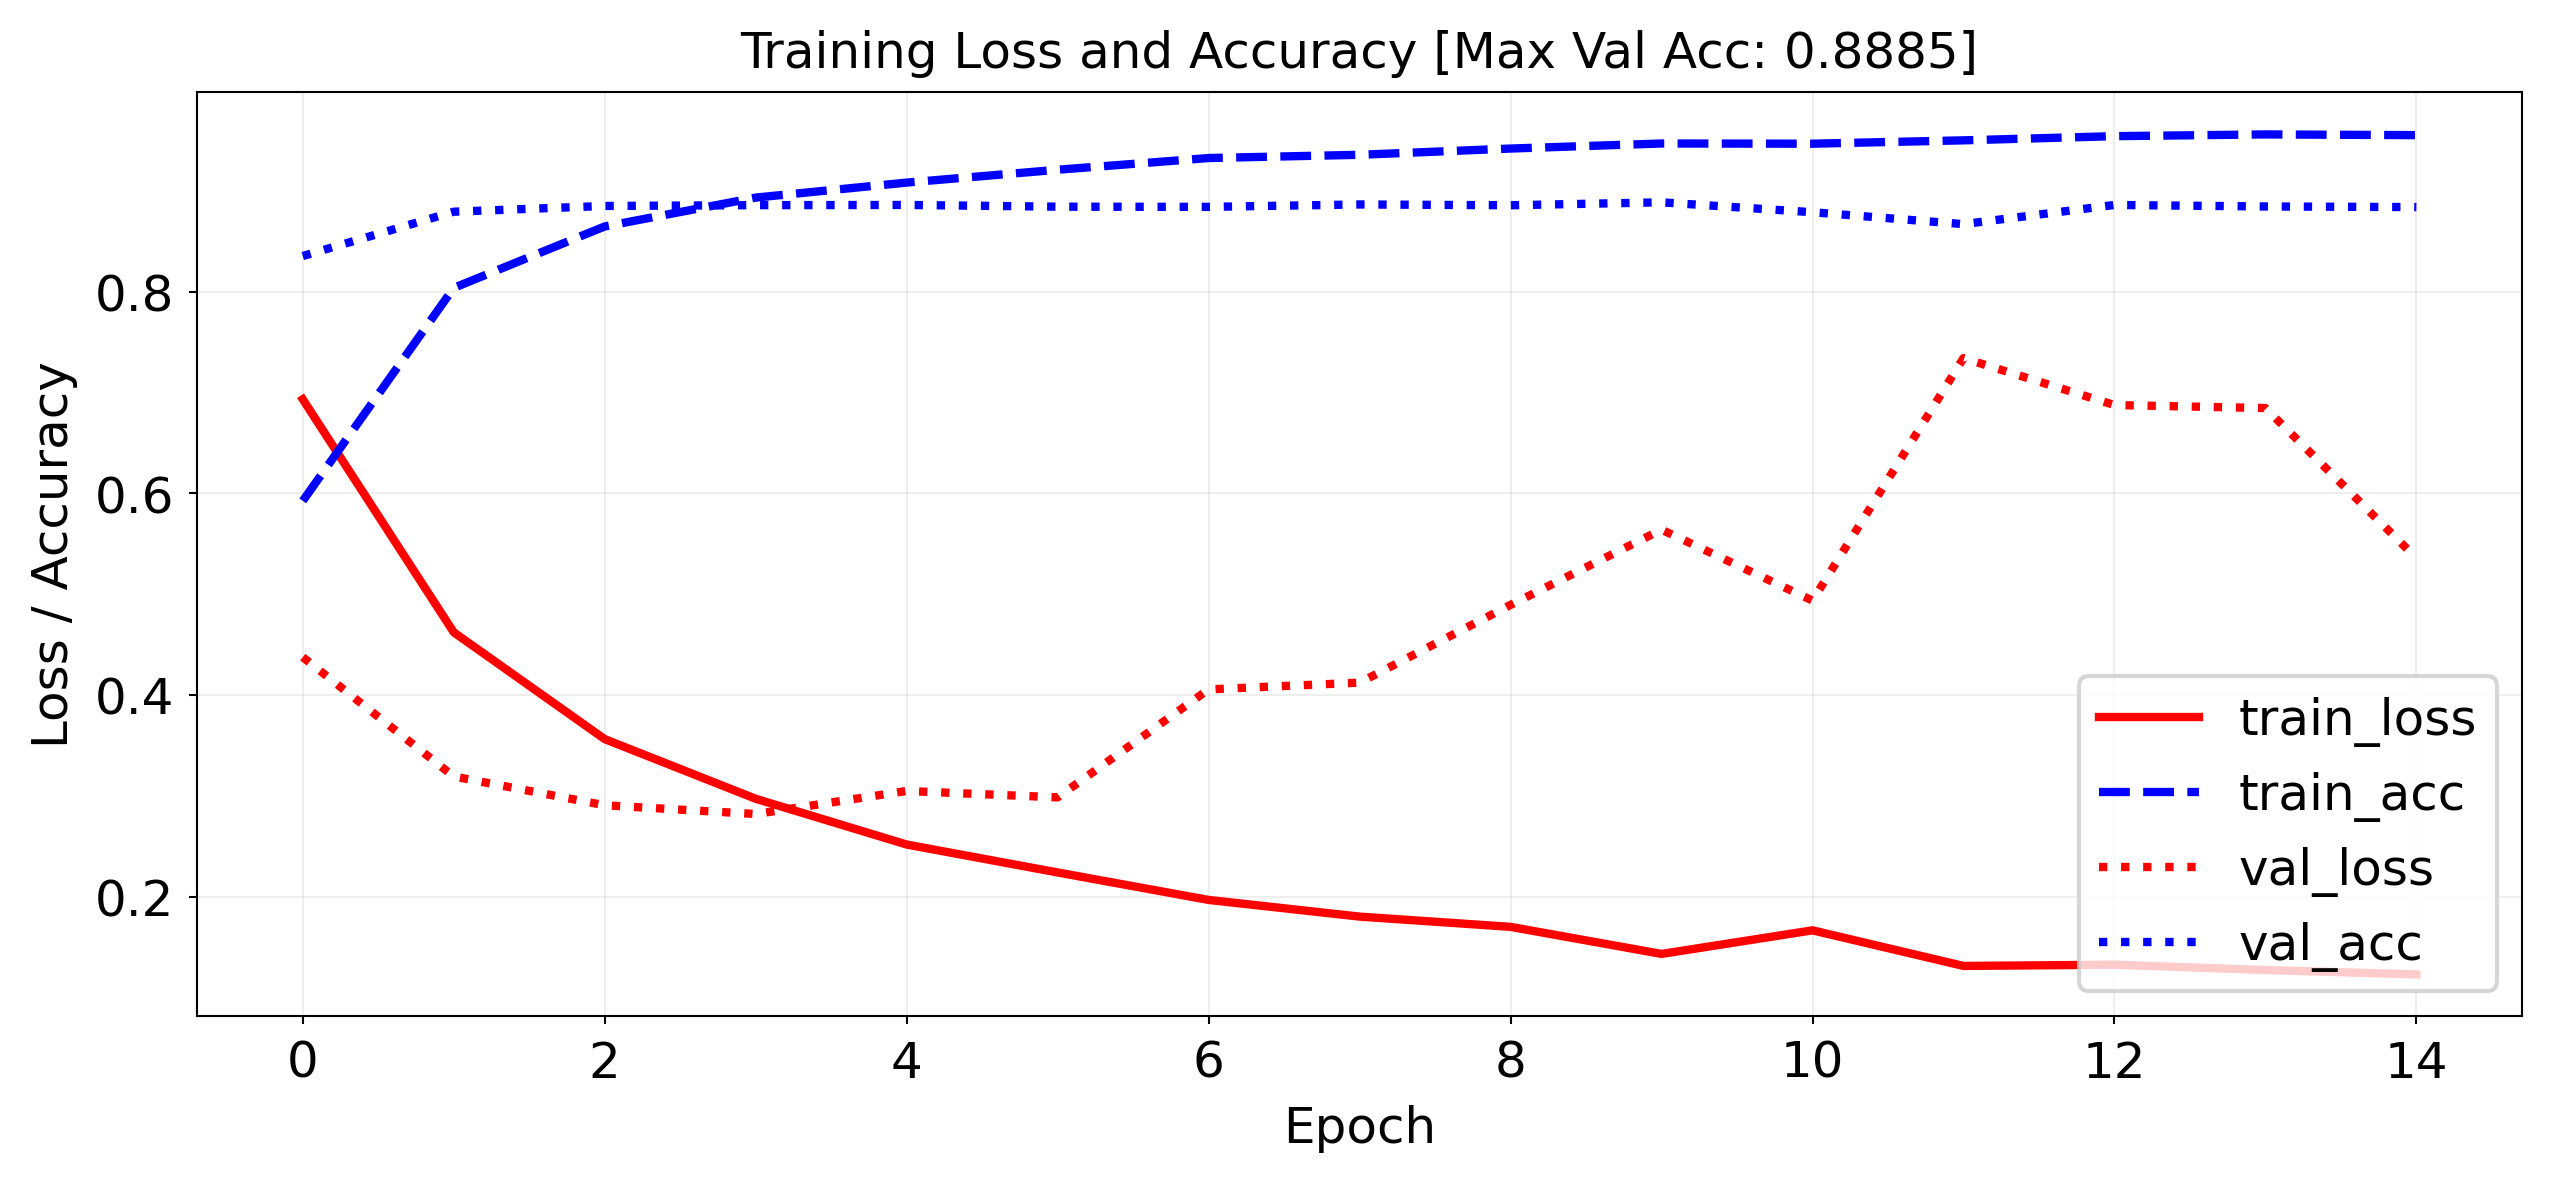

`Trainer.fit` stopped: `max_epochs=15` reached.


In [9]:
import torch
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
import re
from datasets import load_dataset

# 1. Load raw text data from Hugging Face
print("Downloading/Loading IMDB dataset...")
dataset = load_dataset("imdb")

# Shuffle the training dataset so we get a mix of positive and negative reviews
shuffled_train = dataset['train'].shuffle(seed=42)
train_texts, train_labels = shuffled_train['text'], shuffled_train['label']
test_texts, test_labels = dataset['test']['text'], dataset['test']['label']

# 2. Tokenize and build a vocabulary of the top 10,000 words
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

print("Building vocabulary...")
word_counter = Counter()
for text in train_texts:
    word_counter.update(tokenize(text))

# Reserve index 0 for Unknown/Out-of-Vocabulary words, take top 9,999 words
most_common = word_counter.most_common(9999)
word2idx = {word: i + 1 for i, (word, _) in enumerate(most_common)}

# 3. Convert texts to integer sequences
def text_to_sequence(texts):
    return [[word2idx.get(word, 0) for word in tokenize(text)] for text in texts]

print("Converting texts to sequences...")
train_data = text_to_sequence(train_texts)
test_data = text_to_sequence(test_texts)

# 4. Vectorize sequences into one-hot encoded vectors (Your original logic)
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension), dtype=np.float32)
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

print("One-hot encoding data...")
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# --- The rest of your code remains unchanged ---

class IMDBVectorizedDataset(Dataset):
    def __init__(self, features, labels):
        self.x = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    
# Validation split: first 10k for val
x_val, x_partial_train = x_train[:10000], x_train[10000:]
y_val, y_partial_train = y_train[:10000], y_train[10000:]

train_dataset = IMDBVectorizedDataset(x_partial_train, y_partial_train)
val_dataset = IMDBVectorizedDataset(x_val, y_val)
test_dataset = IMDBVectorizedDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512)
test_loader = DataLoader(test_dataset, batch_size=512)

class LivePlotCallback(pl.Callback):
    def __init__(self):
        self.train_losses = []
        self.train_accs = []
        self.val_losses = []
        self.val_accs = []
        self.max_acc = 0

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics

        train_loss = metrics.get("train_loss")
        train_acc = metrics.get("train_acc")
        val_loss = metrics.get("val_loss")
        val_acc = metrics.get("val_acc")

        if all(v is not None for v in [train_loss, train_acc, val_loss, val_acc]):
            self.train_losses.append(train_loss.item())
            self.train_accs.append(train_acc.item())
            self.val_losses.append(val_loss.item())
            self.val_accs.append(val_acc.item())
            self.max_acc = max(self.max_acc, val_acc.item())

            if len(self.train_losses) > 1:
                clear_output(wait=True)
                N = np.arange(0, len(self.train_losses))
                plt.figure(figsize=(10, 4))
                plt.plot(N, self.train_losses, label='train_loss', lw=2, c='r')
                plt.plot(N, self.train_accs, label='train_acc', lw=2, c='b')
                plt.plot(N, self.val_losses, label='val_loss', lw=2, linestyle=":", c='r')
                plt.plot(N, self.val_accs, label='val_acc', lw=2, linestyle=":", c='b')
                plt.title(f"Training Loss and Accuracy [Max Val Acc: {self.max_acc:.4f}]", fontsize=12)
                plt.xlabel("Epoch", fontsize=12)
                plt.ylabel("Loss / Accuracy", fontsize=12)
                plt.tick_params(axis='both', labelsize=12)
                plt.legend(fontsize=12)
                plt.grid(True)
                plt.show()
            
class IMDBClassifier(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10000, 16)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(16, 16)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.sigmoid(self.fc3(x))
        return x.squeeze()

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.binary_cross_entropy(y_hat, y)
        acc = ((y_hat > 0.5) == y.bool()).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        val_loss = F.binary_cross_entropy(y_hat, y)
        val_acc = ((y_hat > 0.5) == y.bool()).float().mean()
        self.log("val_loss", val_loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", val_acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.RMSprop(self.parameters())
    
model = IMDBClassifier()
trainer = pl.Trainer(max_epochs=15, callbacks=[LivePlotCallback()], logger=False, enable_checkpointing=False)
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

#### Predictions
Let's look at a few predictions. Why is the last one so negative?

In [15]:
# 1. Get the trained model into eval mode
model.eval()

# 2. Disable gradient tracking for inference
with torch.no_grad():
    # Convert entire test set to a tensor
    x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

    # Get predictions (using sigmoid output from the model)
    predictions = model(x_test_tensor).numpy()

# 3. Build the reverse index from our existing word2idx
idx2word = {idx: word for word, idx in word2idx.items()}
idx2word[0] = '[UNK]' # Index 0 was our fallback for out-of-vocabulary words

# 4. Function to decode a review
def decode_review(encoded_review):
    return ' '.join([idx2word.get(i, '[UNK]') for i in encoded_review])

print("Review 0:\n", decode_review(test_data[4]))
print("Predicted positiveness:", predictions[4])

print("\nReview 16:\n", decode_review(test_data[16]))
print("Predicted positiveness:", predictions[16])

# 5. Function to encode a new raw text review
def encode_review(text):
    # Relies on the 'tokenize' function we defined in Part 1
    words = tokenize(text)
    return [word2idx.get(word, 0) for word in words]

# Test on a new sentence
sentence = 'the restaurant is not too terrible'
encoded = encode_review(sentence)

# Vectorize (Note: wrap in list to get shape (1, 10000))
vectorized = vectorize_sequences([encoded])  

with torch.no_grad():
    input_tensor = torch.tensor(vectorized, dtype=torch.float32)
    prediction = model(input_tensor).item()

print("\nReview X:\n", sentence)
print(f"Predicted positiveness: {prediction:.4f}")

Review 0:
 first off let me say if you haven t enjoyed a van damme movie since [UNK] you probably will not like this movie most of these movies may not have the best plots or best actors but i enjoy these kinds of movies for what they are this movie is much better than any of the movies the other action guys segal and dolph have thought about putting out the past few years van damme is good in the movie the movie is only worth watching to van damme fans it is not as good as wake of death which i highly recommend to anyone of likes van damme or in hell but in my opinion it s worth watching it has the same type of feel to it as nowhere to run good fun stuff
Predicted positiveness: 0.9986456

Review 16:
 this cheap grainy filmed italian flick is about a couple of [UNK] of a [UNK] in the italian countryside who head up to the house to stay and then find themselves getting killed off by ghosts of people killed in that house br br i wasn t impressed by this it wasn t really that scary mostly

## Word Embeddings
* A word embedding is a numeric vector representation of a word
    * Can be manual or _learned_ from an existing representation (e.g. one-hot)

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_embeddings.png" alt="ml" style="width: 60%; margin-left: auto; margin-right: auto;">

### Learning embeddings from scratch
* Input layer uses fixed length documents (with 0-padding).
* Add an _embedding layer_ to learn the embedding
    * Create $n$-dimensional one-hot encoding.
    * To learn an $m$-dimensional embedding, use $m$ hidden nodes. Weight matrix $W^{n x m}$
    * Linear activation function: $\mathbf{X}_{embed} = W \mathbf{X}_{orig}$.
* Combine all word embeddings into a document embedding (e.g. global pooling).
* Add layers to map word embeddings to the output. Learn embedding weights from data.


<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_embedding_layer.png" alt="ml" style="width: 60%; margin-left: auto; margin-right: auto;">

Let's try this:

```python
max_length = 100 # pad documents to a maximum number of words
vocab_size = 10000 # vocabulary size
embedding_length = 20 # embedding length (more would be better)

self.model = nn.Sequential(
    nn.Embedding(vocab_size, embedding_length),
    nn.AdaptiveAvgPool1d(1),  # global average pooling over sequence
    nn.Linear(embedding_length, 1),
)
```

* Training on the IMDB dataset: slightly worse than using bag-of-words?
    * Embedding of dim 20 is very small, should be closer to 100 (or 300)
    * We don't have enough data to learn a really good embedding from scratch


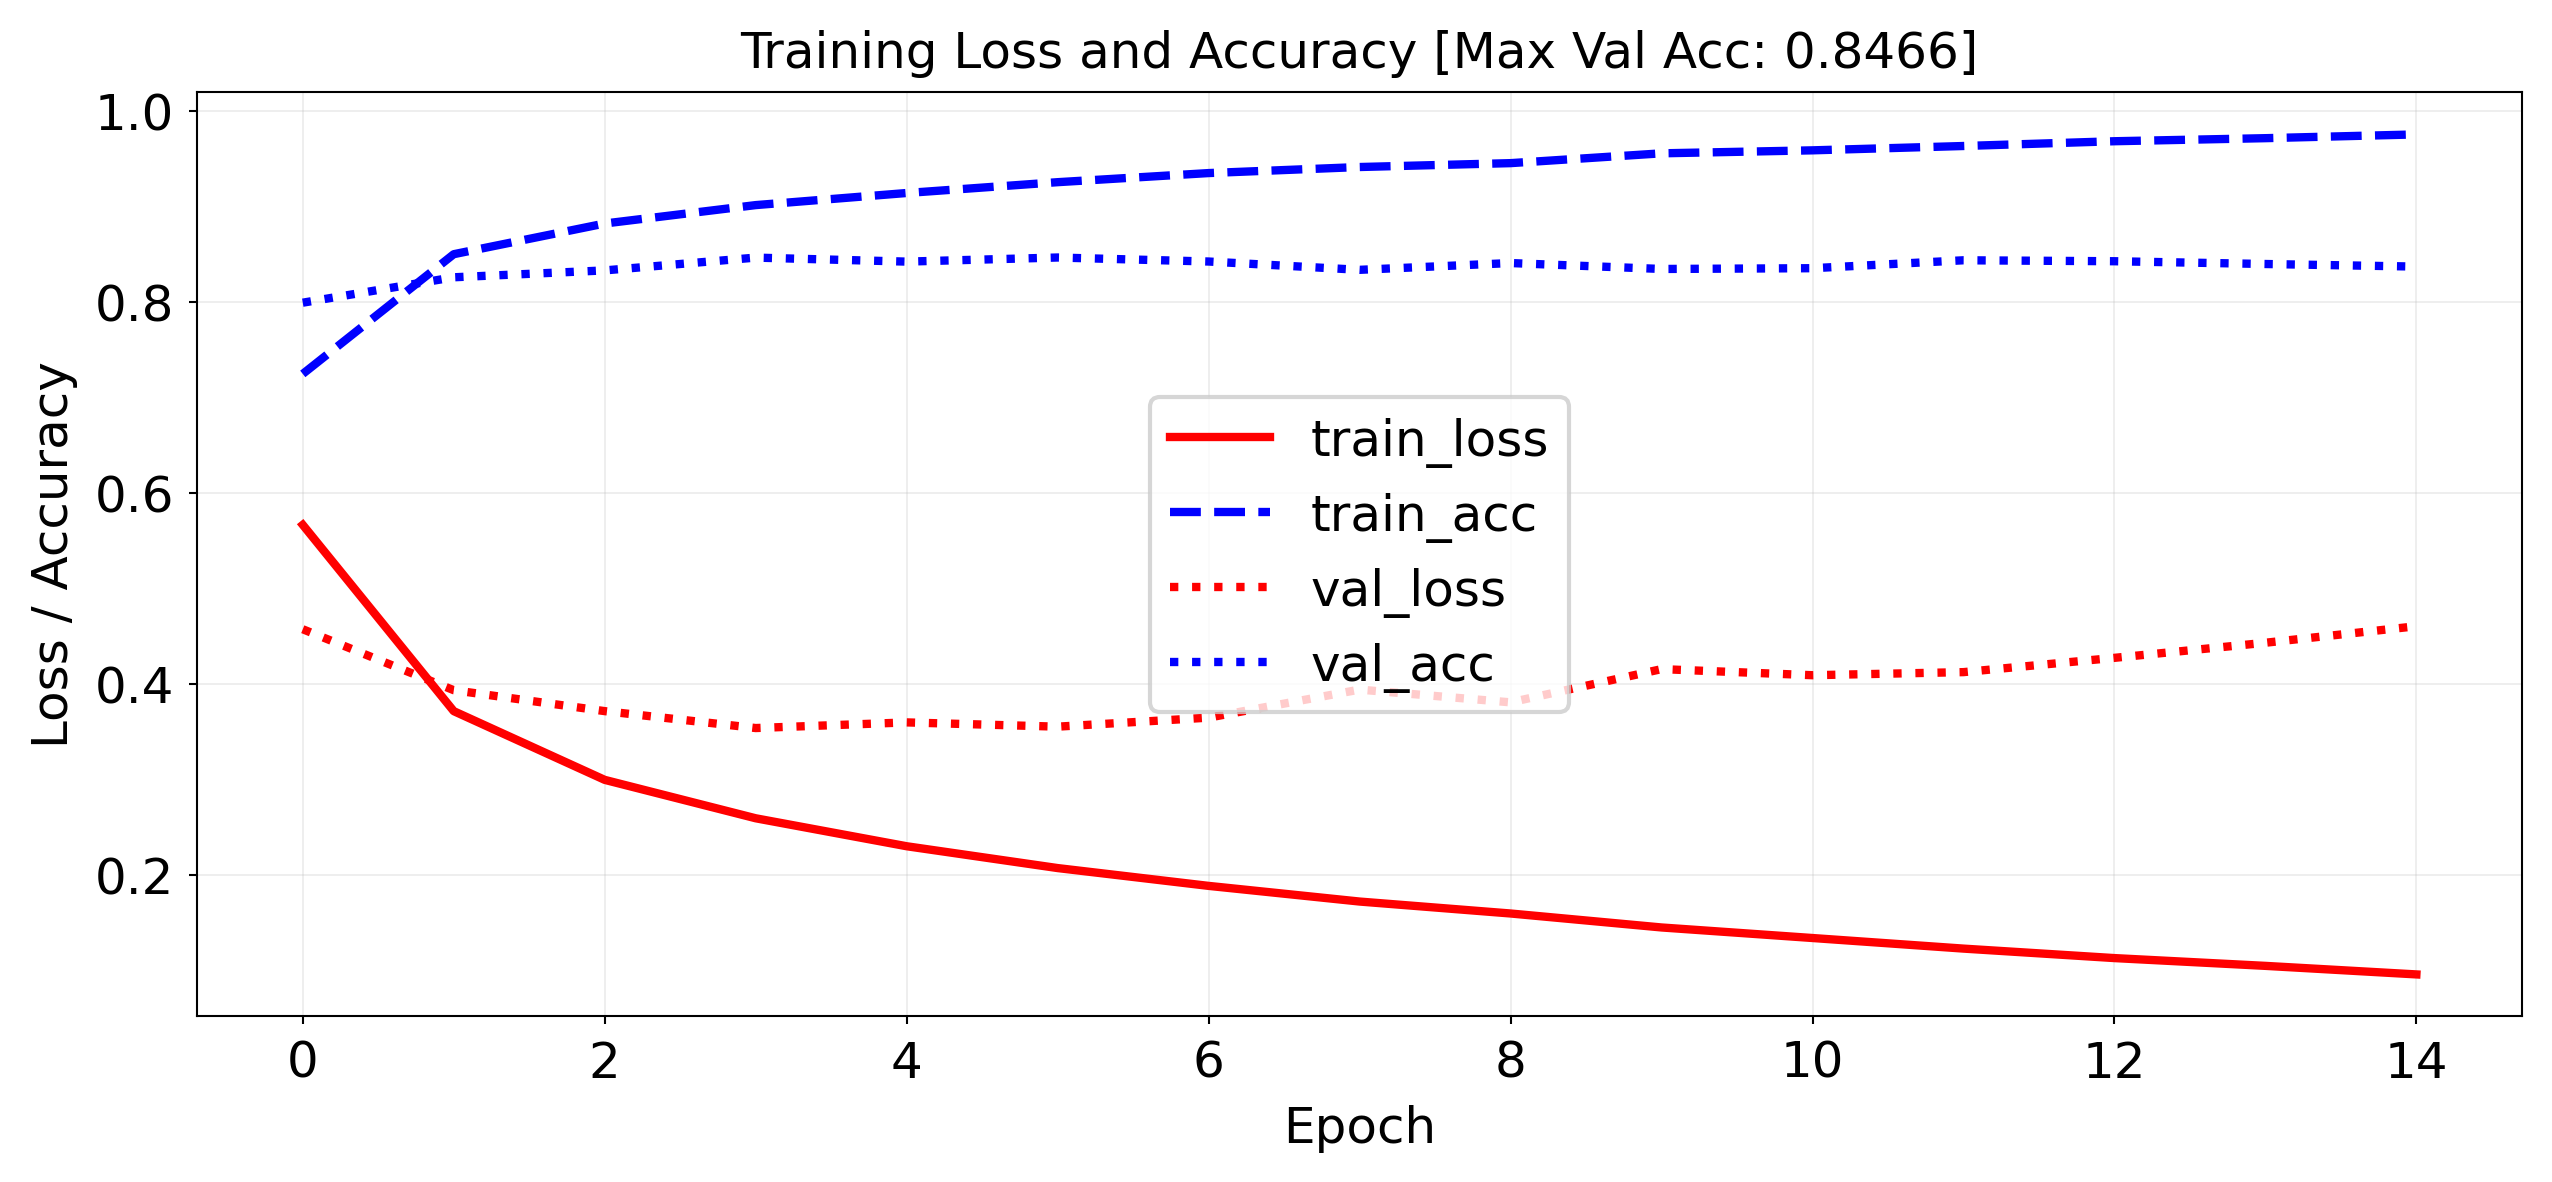

`Trainer.fit` stopped: `max_epochs=15` reached.


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from collections import Counter
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- 1. Load and Shuffle Data from Hugging Face ---
print("Loading and shuffling IMDB dataset...")
dataset = load_dataset("imdb")
shuffled_train = dataset['train'].shuffle(seed=42)

train_texts, train_labels = shuffled_train['text'], shuffled_train['label']
test_texts, test_labels = dataset['test']['text'], dataset['test']['label']

# --- 2. Build Vocabulary and Tokenize ---
print("Building vocabulary...")
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

word_counter = Counter()
for text in train_texts:
    word_counter.update(tokenize(text))

vocab_size = 10000
max_length = 100

# Top 9,999 words (0 is reserved for padding/unknowns)
most_common = word_counter.most_common(vocab_size - 1)
word2idx = {word: i + 1 for i, (word, _) in enumerate(most_common)}

def text_to_sequence(texts):
    return [[word2idx.get(word, 0) for word in tokenize(text)] for text in texts]

print("Converting texts to sequences...")
train_data = text_to_sequence(train_texts)
test_data = text_to_sequence(test_texts)

# --- 3. Custom Pad Sequences (Replaces Keras) ---
def pad_sequences_custom(sequences, maxlen, padding='pre', truncating='pre', value=0):
    """Pure NumPy replacement for Keras pad_sequences"""
    result = np.full((len(sequences), maxlen), value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        if len(seq) == 0:
            continue
        # Truncate
        if len(seq) > maxlen:
            seq = seq[-maxlen:] if truncating == 'pre' else seq[:maxlen]
        # Pad
        if padding == 'pre':
            result[i, -len(seq):] = seq
        else:
            result[i, :len(seq)] = seq
    return result

print("Padding sequences...")
x_train = pad_sequences_custom(train_data, maxlen=max_length)
x_test = pad_sequences_custom(test_data, maxlen=max_length)

y_train = np.array(train_labels, dtype=np.float32)
y_test = np.array(test_labels, dtype=np.float32)

# --- 4. Dataset and Model Definitions ---

class IMDBVectorizedDataset(Dataset):
    def __init__(self, features, labels):
        self.x = torch.tensor(features, dtype=torch.long) # Needs long for nn.Embedding
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class IMDBEmbeddingModel(pl.LightningModule):
    def __init__(self, vocab_size=10000, embedding_length=20, max_length=100):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_length)
        self.pooling = nn.AdaptiveAvgPool1d(1)  # GlobalAveragePooling1D equivalent
        self.fc = nn.Linear(embedding_length, 1)

    def forward(self, x):
        # x: (batch, max_length)
        embedded = self.embedding(x)  # (batch, max_length, embedding_length)
        embedded = embedded.permute(0, 2, 1)  # for AdaptiveAvgPool1d → (batch, embed_dim, seq_len)
        pooled = self.pooling(embedded).squeeze(-1)  # → (batch, embed_dim)
        output = torch.sigmoid(self.fc(pooled))  # → (batch, 1)
        return output.squeeze()

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.binary_cross_entropy(y_hat, y)
        acc = ((y_hat > 0.5) == y.bool()).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        val_loss = F.binary_cross_entropy(y_hat, y)
        val_acc = ((y_hat > 0.5) == y.bool()).float().mean()
        self.log("val_loss", val_loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", val_acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.RMSprop(self.parameters())

# Validation split
x_val, x_partial_train = x_train[:10000], x_train[10000:]
y_val, y_partial_train = y_train[:10000], y_train[10000:]

train_dataset = IMDBVectorizedDataset(x_partial_train, y_partial_train)
val_dataset = IMDBVectorizedDataset(x_val, y_val)
test_dataset = IMDBVectorizedDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512)
test_loader = DataLoader(test_dataset, batch_size=512)

# Make sure to include your LivePlotCallback class here if you want it to render!

model = IMDBEmbeddingModel(vocab_size=vocab_size, embedding_length=20, max_length=max_length)

trainer = pl.Trainer(
    max_epochs=15,
    logger=False,
    enable_checkpointing=False,
    callbacks=[LivePlotCallback()] # Uncomment if LivePlotCallback is defined above
)

print("Starting training...")
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

### Pre-trained embeddings
* With more data we can build better embeddings, but we also need more labels
* Solution: transfer learning! Learn embedding on auxiliary task that doesn't require labels 
    * E.g. given a word, predict the surrounding words.
    * Also called self-supervised learning. Supervision is provided by data itself
* Freeze embedding weights to produce simple word embeddings, or finetune to a new tasks
* Most common approaches:
    * Word2Vec: Learn neural embedding for a word based on surrounding words
    * FastText: learns embedding for character n-grams
        * Can also produce embeddings for new, unseen words
    * GloVe (Global Vector): Count co-occurrences of words in a matrix
        * Use a low-rank approximation to get a latent vector representation

#### Word2Vec
- Move a window over text to get $C$ context words ($V$-dim one-hot encoded)
- Add embedding layer with $N$ linear nodes, global average pooling, and softmax layer(s)
- CBOW: predict word given context, use weights of last layer $W^{'}_{NxV}$ as embedding
- Skip-Gram: predict context given word, use weights of first layer $W^{T}_{VxN}$ as embedding
    - Scales to larger text corpora, learns relationships between words better

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/09_word_embeddings_3.png" alt="ml" style="width: 55%; margin-left: auto; margin-right: auto;"/>

#### Word2Vec properties
* Word2Vec happens to learn [interesting relationships](https://www.aclweb.org/anthology/N13-1090/) between words
    * Simple vector arithmetic can map words to plurals, conjugations, gender analogies,...
    * e.g. Gender relationships: $vec_{king} - vec_{man} + vec_{woman} \sim vec_{queen}$ 
    * PCA applied to embeddings shows Country - Capital relationship
* Careful: embeddings can capture [gender and other biases](https://arxiv.org/abs/1607.06520) present in the data.
    * Important unsolved problem!

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/word2vec.png" alt="ml" style="width: 80%; margin-left: auto; margin-right: auto;"/>

### Doc2Vec
* Alternative way to combine word embeddings (instead of global pooling)
* Adds a paragraph (or document) embedding: learns how paragraphs (or docs) relate to each other
    * Captures document-level semantics: context and meaning of entire document
* Can be used to determine semantic similarity between documents. 
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/doc2vec.png" alt="ml" style="width:50%; margin-left: auto; margin-right: auto;"/>

#### FastText
* Limitations of Word2Vec:
    * Cannot represent new (out-of-vocabulary) words
    * Similar words are learned independently: less efficient (no parameter sharing)
        * E.g. 'meet' and 'meeting'
* FastText: same model, but uses _character n-grams_
    * Words are represented by all character n-grams of length 3 to 6
        * "football" 3-grams: <fo, foo, oot, otb, tba, bal, all, ll>
    * Because there are so many n-grams, they are hashed (dimensionality = bin size)
    * Representation of word "football" is sum of its n-gram embeddings
* Negative sampling: also trains on random negative examples (out-of-context words)
    * Weights are updated so that they are _less_ likely to be predicted

#### Global Vector model (GloVe)
* Builds a co-occurence matrix $\mathbf{X}$: counts how often 2 words occur in the same context
* Learns a k-dimensional embedding $W$ through matrix factorization with rank k
    * Actually learns 2 embeddings $W$ and $W'$ (differ in random initialization)
* Minimizes loss $\mathcal{L}$, where $b_i$ and $b'_i$ are bias terms and $f$ is a weighting function

$$\mathcal{L} = \sum_{i,j=1}^{V} f(\mathbf{X}_{ij}) (\mathbf{w_i} \mathbf{w'_j} + b_i + b'_j - log(\mathbf{X}_{ij}))^2$$

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/glove3.png" alt="ml" style="width: 80%; margin-left: auto; margin-right: auto;"/>

Let's try this

* Download the [GloVe embeddings trained on Wikipedia](https://nlp.stanford.edu/projects/glove)
* We can now get embeddings for 400,000 English words
* E.g. 'queen' (50 first values of 300-dim embedding)

In [22]:
# To find the original data files, see
# http://nlp.stanford.edu/data/glove.6B.zip
# http://www.cs.cmu.edu/afs/cs.cmu.edu/project/theo-20/www/data/news20.tar.gz

# Build an index so that we can later easily compose the embedding matrix
data_dir = '../data'
embeddings_index = {}
with open(os.path.join(data_dir, 'glove.txt')) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print('Found %s word vectors.' % len(embeddings_index))

Found 400000 word vectors.


In [23]:
embeddings_index['queen'][0:50]

array([-0.222,  0.065, -0.086,  0.513,  0.325, -0.129,  0.083,  0.092,
       -0.309, -0.941, -0.089, -0.108,  0.211,  0.701,  0.268, -0.04 ,
        0.174, -0.308, -0.052, -0.175, -0.841,  0.192, -0.138,  0.385,
        0.272, -0.174, -0.466, -0.025,  0.097,  0.301,  0.18 , -0.069,
       -0.205,  0.357, -0.283,  0.281, -0.012,  0.107, -0.244, -0.179,
       -0.132, -0.17 , -0.594,  0.957,  0.204, -0.043,  0.607, -0.069,
        0.523, -0.548], dtype=float32)

* Same simple model, but with frozen GloVe embeddings: much worse!
* Linear layer is too simple. We need something more complex -> transformers :)

```python
embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)
self.model = nn.Sequential(
    nn.Embedding.from_pretrained(embedding_tensor, freeze=True),
    nn.AdaptiveAvgPool1d(1),
    nn.Linear(embedding_tensor.shape[1], 1))
```

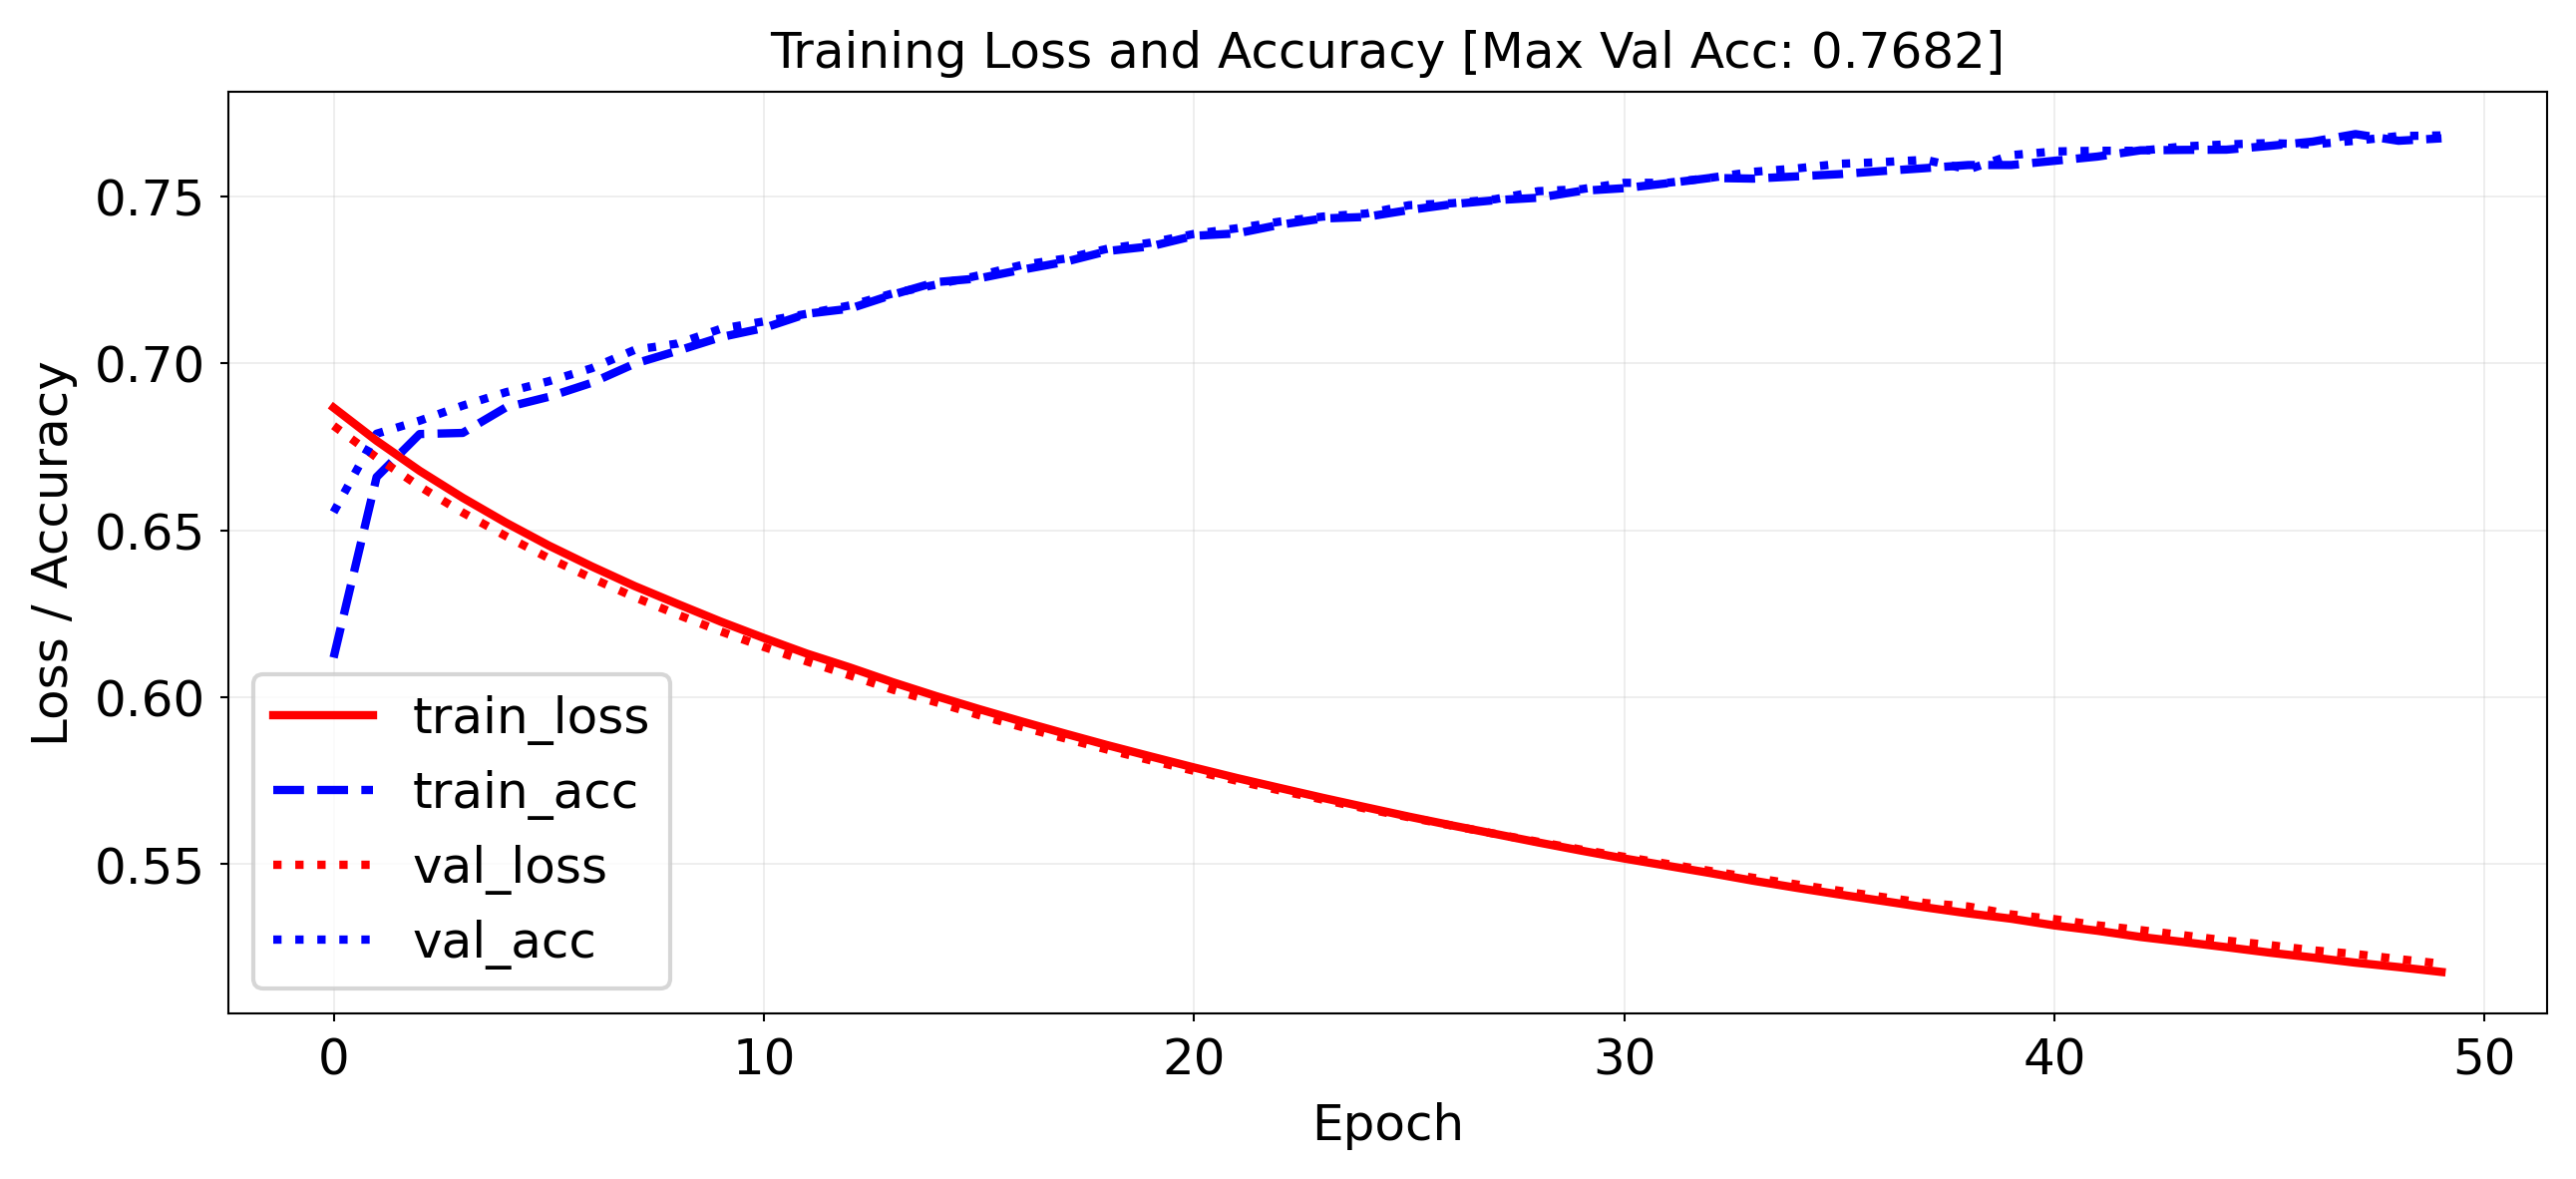

`Trainer.fit` stopped: `max_epochs=50` reached.


In [26]:
# --- Load GloVe Embeddings ---
embedding_dim = 300
glove_path = "../data/glove.txt" # Make sure this path is correct!

print("Loading GloVe embeddings into memory...")
embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        # Some GloVe files have errors; we handle them by catching value errors
        try:
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = vector
        except ValueError:
            pass 

vocab_size = 10000
embedding_matrix = np.zeros((vocab_size, embedding_dim))
missing = 0

# THE FIX: We use word2idx (our custom dict) instead of Keras's word_index
for word, i in word2idx.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
        else:
            missing += 1

print(f"{missing} words from our vocabulary were not found in GloVe.")

# --- Define the Model ---

class Permute(nn.Module):
    def __init__(self, *dims):
        super().__init__()
        self.dims = dims

    def forward(self, x):
        return x.permute(*self.dims)

class Squeeze(nn.Module):
    def __init__(self, dim=-1):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        return x.squeeze(self.dim)

class FrozenGloVeModel(pl.LightningModule):
    def __init__(self, embedding_matrix, max_length=100):
        super().__init__()
        # Load our pre-trained NumPy matrix into a PyTorch tensor
        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

        self.model = nn.Sequential(
            # freeze=True means we won't update GloVe weights during training
            nn.Embedding.from_pretrained(embedding_tensor, freeze=True),
            Permute(0, 2, 1),
            nn.AdaptiveAvgPool1d(1),
            Squeeze(dim=-1),
            nn.Linear(embedding_tensor.shape[1], 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.binary_cross_entropy(y_hat, y)
        acc = ((y_hat > 0.5) == y.bool()).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        val_loss = F.binary_cross_entropy(y_hat, y)
        val_acc = ((y_hat > 0.5) == y.bool()).float().mean()
        self.log("val_loss", val_loss, on_epoch=True)
        self.log("val_acc", val_acc, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters())
    
# --- Train the Model ---

# Initialize the model with the GloVe matrix we just built
model = FrozenGloVeModel(embedding_matrix=embedding_matrix, max_length=100)

trainer = pl.Trainer(
    max_epochs=50,
    logger=False,
    enable_checkpointing=False,
    callbacks=[LivePlotCallback()]
)

print("Starting training with frozen GloVe embeddings...")
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
        
        
        
        

## Sequence-to-sequence (seq2seq) models
* Global average pooling or flattening destroys the word order
* We need to model sequences explictly, e.g.:
    * 1D convolutional models: run a 1D filter over the input data
        * Fast, but can only look at small part of the sentence
    * Recurrent neural networks (RNNs)
        * Can look back at the entire previous sequence
        * Much slower to train, have limited memory in practice
    * Attention-based networks (Transformers)
        * Best of both worlds: fast and very long memory

### seq2seq models
* Produce a series of output given a series of inputs over time
* Can handle sequences of different lengths
    * Label-to-sequence, Sequence-to-label, seq2seq,...
    * Autoregressive models (e.g. predict the next character, unsupervised)


<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_seq2seq.png" alt="ml" style="width: 80%; margin-left: auto; margin-right: auto;"/>

### 1D convolutional networks
* Similar to 2D convnets, but moves only in 1 direction (time)
    * Extract local 1D patch, apply filter (kernel) to every patch
    * Pattern learned can later be recognized elsewhere (translation invariance)
* Limited memory: only sees a small part of the sequence (receptive field)
    * You can use multiple layers, dilations,... but becomes expensive
* Looks at 'future' parts of the series, but can be made to look only at the past
    * Known as 'causal' models (not related to causality)

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_1dconv.png" alt="ml" style="width:100%;"/>

* Same embedding, but add 2 `Conv1D` layers and `MaxPooling1D`. 
```python
model = nn.Sequential(
    nn.Embedding(num_embeddings=10000, embedding_dim=embedding_dim),
    nn.Conv1d(in_channels=embedding_dim, out_channels=32, kernel_size=7),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=5),
    nn.Conv1d(in_channels=32, out_channels=32, kernel_size=7),
    nn.ReLU(),
    nn.AdaptiveAvgPool1d(1),  # GAP
    nn.Flatten(),             # (batch, 32, 1) → (batch, 32)
    nn.Linear(32, 1)
)
```

In [27]:
model = nn.Sequential(
    nn.Embedding(num_embeddings=10000, embedding_dim=embedding_dim),  # embedding_layer
    nn.Conv1d(in_channels=embedding_dim, out_channels=32, kernel_size=7),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=5),
    nn.Conv1d(in_channels=32, out_channels=32, kernel_size=7),
    nn.ReLU(),
    nn.AdaptiveAvgPool1d(1),  # equivalent to GlobalAveragePooling1D
    nn.Flatten(),             # flatten (batch, 32, 1) → (batch, 32)
    nn.Linear(32, 1),
    nn.Sigmoid()
)


### Recurrent neural networks (RNNs)
* Recurrent connection: concats output to next input
${\color{orange} h_t} = \sigma \left( {\color{orange} W } \left[ \begin{array}{c} {\color{blue}x}_t \\ {\color{orange} h}_{t-1} \end{array} \right] + b \right)$
* Unbounded memory, but training requires _backpropagation through time_
    * Requires storing previous network states (slow + lots of memory)
    * Vanishing gradients strongly limit practical memory
* Improved with _gating_: learn what to input, forget, output (LSTMs, GRUs,...)

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_rnn.png" alt="ml" style="width:70%;"/>

### Simple self-attention
* Maps a _set_ of inputs to a set of outputs (_without_ learned weigths)


<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/selfattention.png" alt="ml" style="width:50%;"/>

### Simple self-attention
* Compute dot product of input vector $x_i$ with every $x_j$ (including itself): ${\color{Orange} w_{ij}}$
* Compute softmax over all these weights (positive, sum to 1)
* Multiply by each input vector, and sum everything up
* Can be easily vectorized: ${\color{green} Y}^T = {\color{orange} W}{\color{blue} X^T}$, ${\color{orange} W} = \textrm{softmax}( {\color{blue} X}^T {\color{blue}X} )$

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_selfattention.png" alt="ml" style="width:70%;"/>

* For each output, we mix information from all inputs according to how 'similar' they are
    * The set of weights ${\color{Orange} w_{i}}$ for a given token is called the attention vector
    * It says how much 'attention' each token gives to other tokens
* Doesn't learn (no parameters), the embedding of ${\color{blue} X}$ defines self-attention
    * We'll learn how to _transform the embeddings_ later
    * That way we can learn different relationships (not just similarity)
* Has no problem looking _very_ far back in the sequence
* Operates on _sets_ (permutation invariant): allows img-to-set, set-to-set,... tasks
    * If the token order matters, we'll have to encode it in the token embedding

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_selfattention.png" alt="ml" style="width:45%;"/>

### Scaled dot products
* Self-attention is powerful because it's mostly a linear operation
* ${\color{green} Y}^T = {\color{orange} W}{\color{blue} X^T}$ is _linear_, there are no vanishing gradients
    * The softmax function only applies to ${\color{orange} W} = \textrm{softmax}( {\color{blue} X}^T {\color{blue}X} )$, not to ${\color{green} Y}^T$
    * Needed to make the attention values sum up nicely to 1 without exploding
* The dot products do get larger as the embedding dimension $k$ gets larger (by a factor $\sqrt{k}$)
    * We therefore normalize the dot product by the input dimension $k$: ${\color{orange}w^{'}_{ij}} = \frac{{\color{blue} x_i}^T \color{blue} x_j}{\sqrt{k}}$
    * This also makes training more stable: large softmas values lead to 'sharp' outputs, making some gradients very large and others very small 
    


### Simple self-attention layer
* Let's add a simple self-attention layer to our movie sentiment model
* Without self-attention, every word would contribute independently (bag of words)
    * The word _terrible_ will likely result in a negative prediction
* Now, we can freeze the embedding, take output ${\color{gray}Y}$, obtain a loss, and do backpropagation so that the self-attention layer can _learn_ that 'not' should invert the meaning of 'terrible'

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_selfattention_layer_train.png" alt="ml" style="width:40%;"/>

### Simple self-attention layer
* Through training, we want the self-attention to learn how certain tokens (e.g. 'not') can affect other tokens / words.
    * E.g. we need to learn to change the representations of $v_{not}$ and $v_{terrible}$ so that they produce a 'correct' (low loss) output
* For that, we do need to add some trainable parameters.

   

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_selfattention_negation.png" alt="ml" style="width:50%;"/>

### Standard self-attention
* We add 3 weight matrices (K, Q, V) and biases to change each vector:
    * $k_i = K x_i + b_k$
    * $q_i = Q x_i + b_q$
    * $v_i = V x_i + b_v$
* The same K, Q, V are used for all tokens depending on whether they are the input token (v), the token we are currently looking at (q), or the token we're comparing with (k)
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_selfattention_kqv3.png" alt="ml" style="width:50%; margin-left: auto; margin-right: auto;"/>

### Sidenote on terminology
* View the set of tokens as a dictionary 
`s = {a: v_a, b: v_b, c: v_c}`
* In a dictionary, the third output (for key c) would simple be `s[c] = v_c`
* In a _soft_ dictionary, it's a weighted sum: $s[c] = w_a * v_a + w_b * v_b + w_c * v_c$
* If $w_i$ are dot products: $s[c] = (k_a\cdot q_c) * v_a + (k_b\cdot q_c) * v_b + (k_c\cdot q_c) * v_c$
* We _blend_ the influence of every token based on their learned relations with other tokens
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_selfattention_kqv_dict.png" alt="ml" style="width:40%; margin-left: auto; margin-right: auto;"/>

### Intuition
* We _blend_ the influence of every token based on their learned 'relations' with other tokens
* Say that we need to learn how 'negation' works
    * The 'query' vector could be trained (via Q) to say something like 'are there any negation words?'
    * A token (e.g. 'not'), transformed by K, could then respond very positively if it is

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_selfattention_kqv_not2.png" alt="ml" style="width:40%; margin-left: auto; margin-right: auto;"/>

### Single-head self-attention
* There are different relations to model within a sentence.
* The same input token, e.g. $v_{terrible}$ can relate completely differently to other kinds of tokens
    * But we only have one set of K, V, and Q matrices
* To better capture multiple relationships, we need multiple self-attention operations (expensive)

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_properties.png" alt="ml" style="width:40%; margin-left: auto; margin-right: auto;"/>

### Multi-head self-attention
* What if we project the input embeddings to a lower-dimensional embedding $k$?
* Then we could learn multiple self-attention operations in parallel
* Effectively, we split the self-attention in multiple heads
    * Each applies a separate low-dimensional self attention (with $K^{kxk},Q^{kxk},V^{kxk}$)
* After running them (in parallel), we concatenate their outputs.

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_multihead_attention.png" alt="ml" style="width:60%;"/>

## Transformer model
* Repeat self-attention multiple times in controlled fashion
* Works for sequences, images, graphs,... (learn how sets of objects interact)
* Models consist of multiple transformer blocks, usually:
    * Layer normalization (every input is normalized independently)
    * Self-attention layer (learn interactions)
    * Residual connections (preserve gradients in deep networks)
    * Feed-forward layer (learn mappings)
    

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_transformer_model.png" alt="ml" style="width:60%;"/>

### Positional encoding
* We need some way to tell the self-attention layer about position in the sequence
* Represent position by vectors, using some easy-to-learn predictable pattern
    * Add these encodings to vector embeddings
    * Gives information on how far one input is from the others
* Other techniques exist (e.g. relative positioning)

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_encoding2.png" alt="ml" style="width:70%;"/>

### Autoregressive models

* Models that predict future values based on past values of the same stream
* Output token is mapped to list of probabilities, sampled with softmax (with temperature) 
* Problem: self-attention can simply look ahead in the stream
    * We need to make the transformer blocks _causal_

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_autoregressive2.png" alt="ml" style="width:60%; margin-left: auto; margin-right: auto;"/>

### Masked self-attention
* Simple solution: simply mask out any attention weights from current to future tokens 
* Replace with -infinity, so that after softmax they will be 0


<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_maskedse.png" alt="ml" style="width:60%; margin-left: auto; margin-right: auto;"/>

### Famous transformers
* "Attention is all you need": first paper to use attention without CNNs or RNNs
* Encoder-Decoder architecture for translation: (k, q) to source attention layer 
* We'll reproduce this (partly) in the Lab 6 tutorial :)

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_aiayn.png" alt="ml" style="width:40%; margin-left: auto; margin-right: auto;"/>

### GPT 3
* Decoder-only, single stack of 96 transformer blocks (and 96 heads)
* Sequence size 2048, input dimensionality 12,288, 175B parameters
* Trained on entire common crawl dataset (1 epoch)
    * Additional training on high-quality data (Wikipedia,...)
* [Excellent animation by 1b3b](https://youtu.be/wjZofJX0v4M?t=305)
* [GPT from scratch by A. Karpathy](https://www.youtube.com/watch?v=kCc8FmEb1nY)


<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_gpt.png" alt="ml" style="width:40%; margin-left: auto; margin-right: auto;"/>

### GPT 4
* Likely a 'mixtures of experts' model
    * Router (small MLP) selects which subnetworks (e.g. 2) to use given input
    * Predictions get ensembled
* Allows scaling up parameter count without proportionate (inference) cost
* Also better data, more human-in-the-loop training (RLHF),...

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_switch_transformer2.png" alt="ml" style="width:60%; margin-left: auto; margin-right: auto;"/>


## Summary
* Tokenization
    * Find a good way to split data into tokens
* Word/Image embeddings (for initial embeddings)
    * For text: Word2Vec, FastText, GloVe
    * For images: MLP, CNN,...
* Sequence-to-sequence models
    * 1D convolutional nets (fast, limited memory)
    * RNNs (slow, also quite limited memory)
* Transformers
    * Self-attention (allows very large memory)
    * Positional encoding
    * Autoregressive models
* Next: Vision transformers and multimodal models

Acknowledgement

Several figures came from the excellent [VU Deep Learning course](https://dlvu.github.io/).